
# Scientific programming video game prediction

## Library justification
The first step of running this code would be to import the packages used throughout the script:
- For data handling and preprocessing the main packages that are important are `pandas` for data manipulation and `parallel_coordinates` for visualizing multivariate patterns. `numpy` provides optimized numerical operations and array handling.
- `scikit-learn` is the core library used for all machine learning throughout the script. The package is also used for importing the classification models.
- For multivariate outlier detection, `pyod.modles.KNN` and `pyod.models.IForest` are used. 
- `matplotlib.pyplot` and `seaborn` are used to create visualizations. `scipy.cluster.hierarchy` is used to perform hierarchical clustering and dendogram visualizations.
- `tqdm` and `joblib` are used to add a progress bar and to enable parallel computation to speed up certain processes.

In [ ]:
# Execute this cell to import the required packages
import pandas as pd
from pandas.plotting import parallel_coordinates
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from tqdm import tqdm
from joblib import Parallel, delayed

# Loading the dataset + descriptive stats + imputation

- This block of code loads the data as well as the clean version of the data. 
- It checks whether there is missingness in the data or impossible values.
- Boxplots are created for every numerical column in the dataset to see the distributions. 
- An iterative imputer using random forest is created and used to impute the nan values in the data.
- Unsupervised PCA, t-SNE and K-means clustering plots are made to visualize the data
- Without parallel computation, imputation took ~15 min and now it is reduced to only ~2 mins.

Number of duplicate game IDs: 0
redDeaths                       2
blueCSPerMin                    2
blueWardsDestroyed              1
blueWardsPlaced                 1
redWardsPlaced                  1
redFirstBlood                   1
blueDeaths                      1
blueAssists                     1
redExperienceDiff               1
redTotalJungleMinionsKilled     1
redKills                        1
redWardsDestroyed               1
redTotalExperience              1
blueKills                       0
blueWins                        0
gameId                          0
blueFirstBlood                  0
blueTotalMinionsKilled          0
blueAvgLevel                    0
blueTotalExperience             0
blueEliteMonsters               0
blueDragons                     0
blueHeralds                     0
blueTowersDestroyed             0
blueGoldPerMin                  0
blueTotalJungleMinionsKilled    0
blueGoldDiff                    0
blueExperienceDiff              0
blueTotalGold   

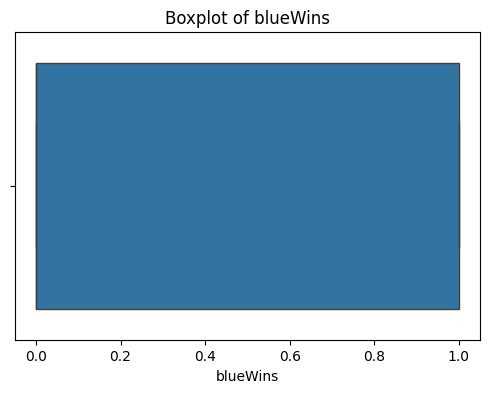

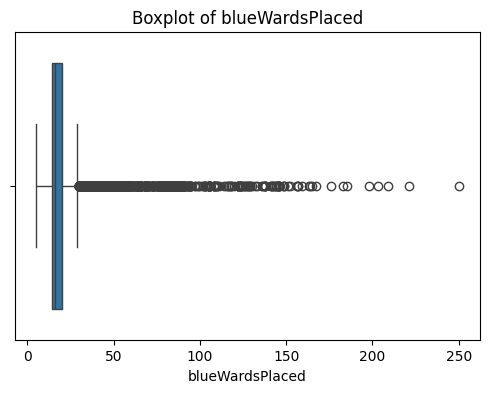

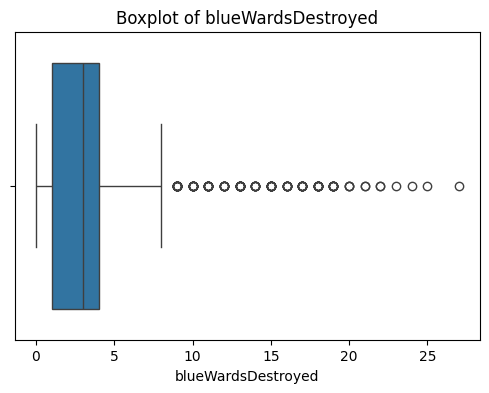

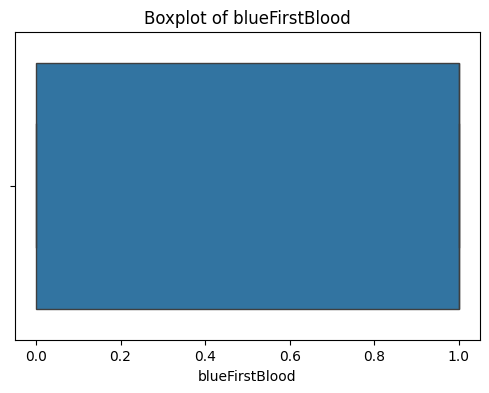

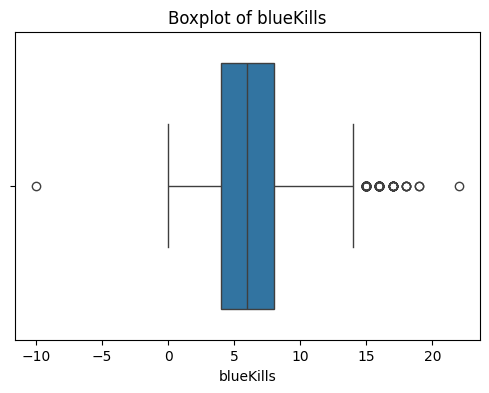

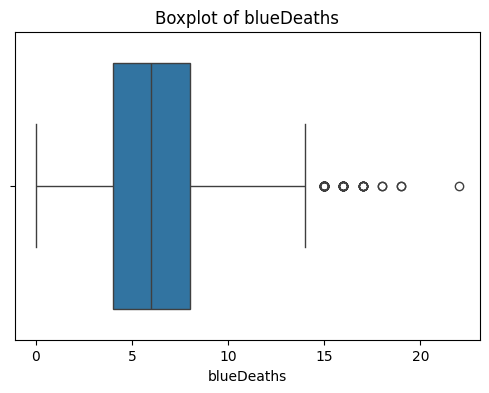

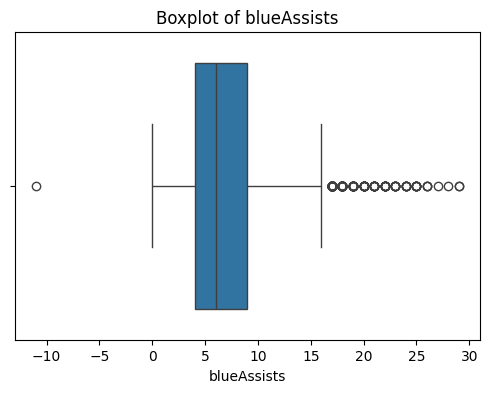

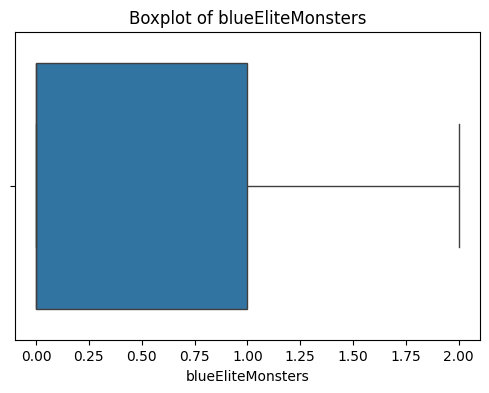

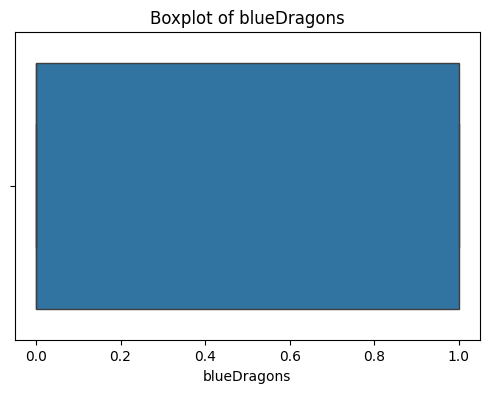

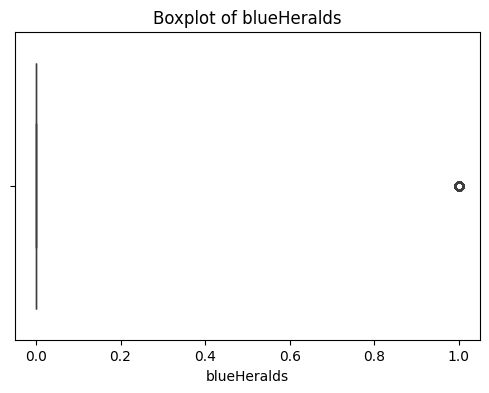

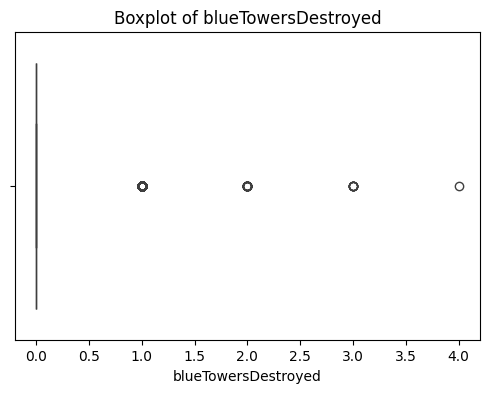

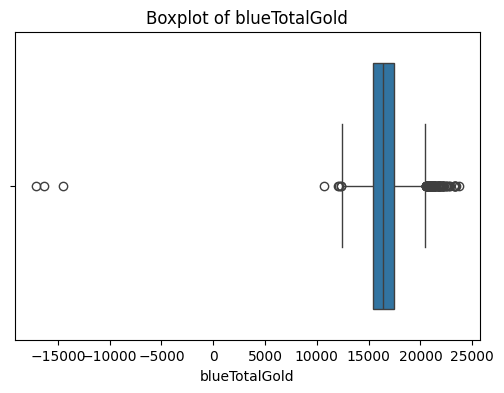

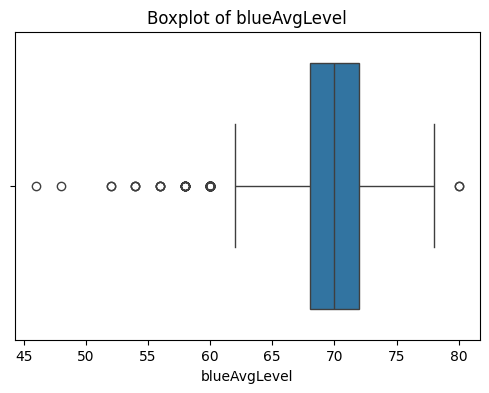

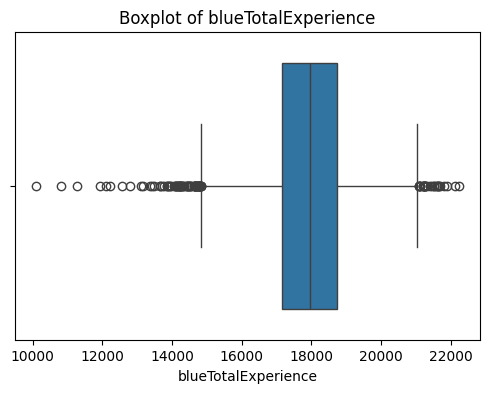

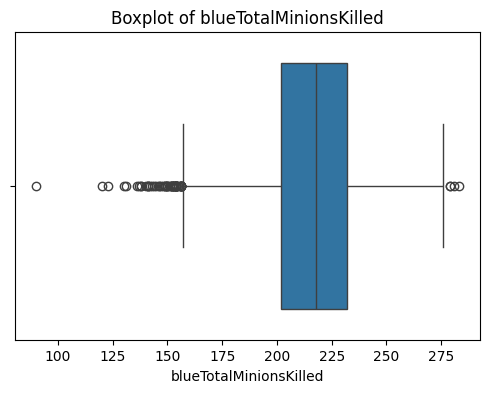

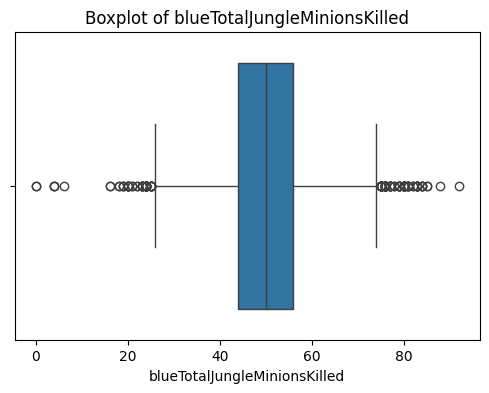

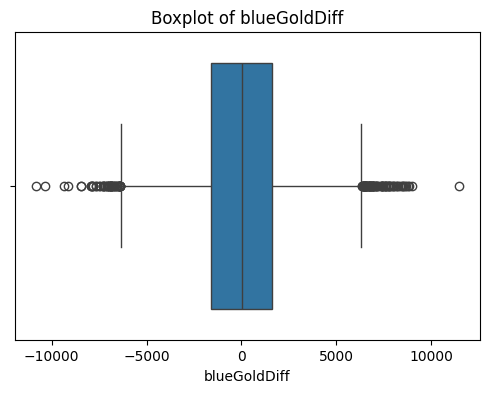

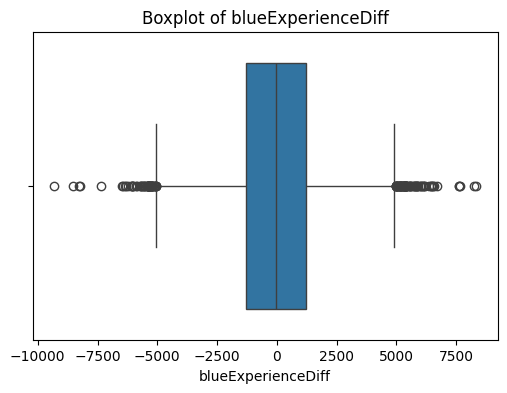

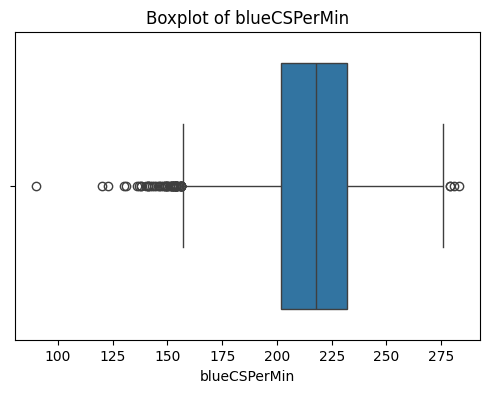

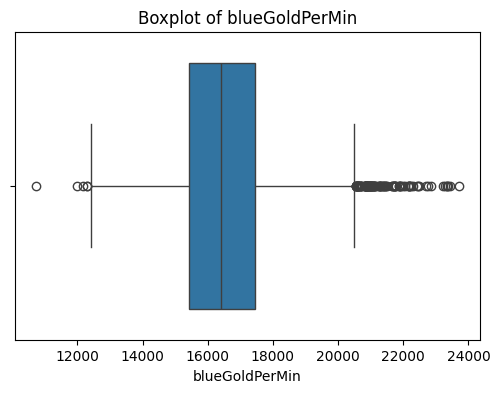

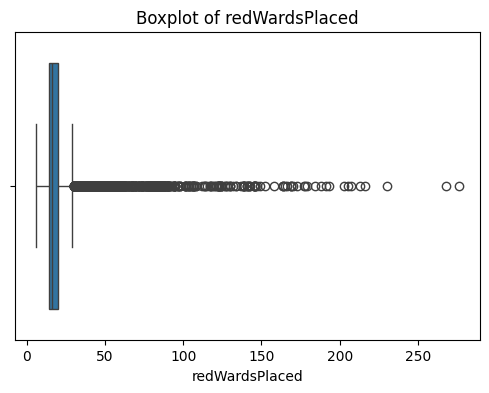

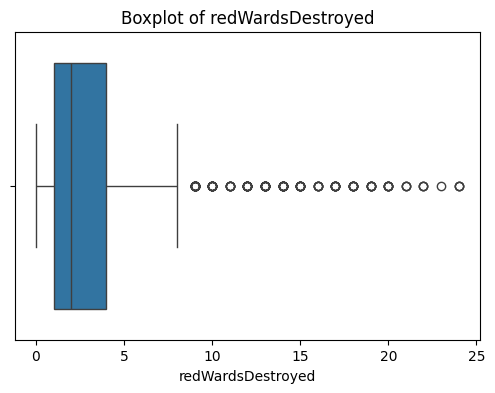

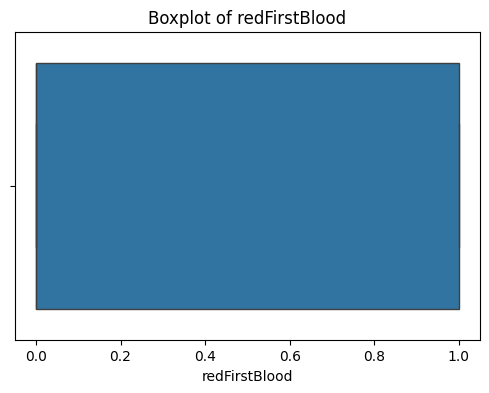

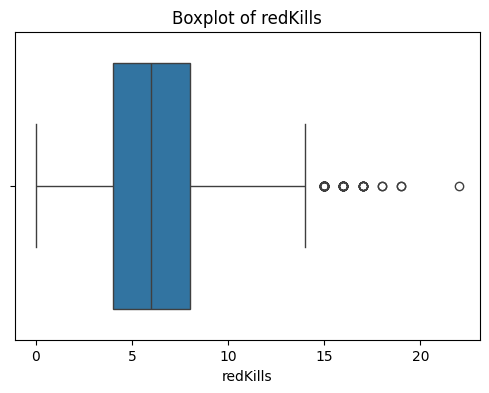

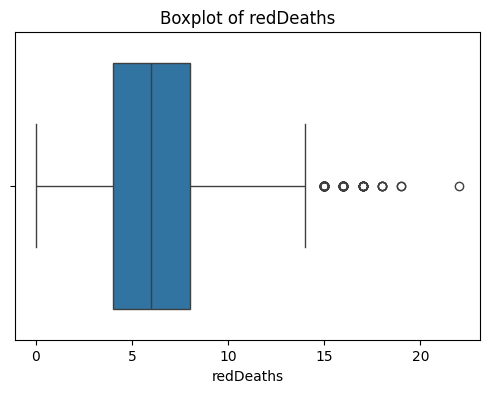

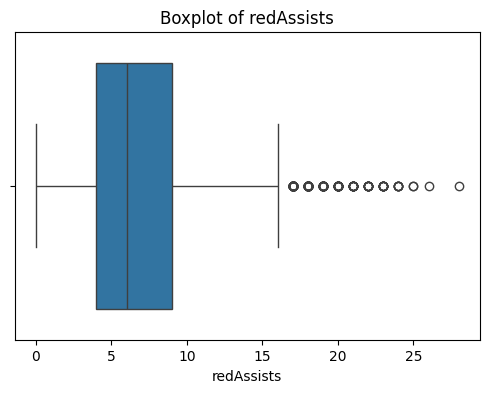

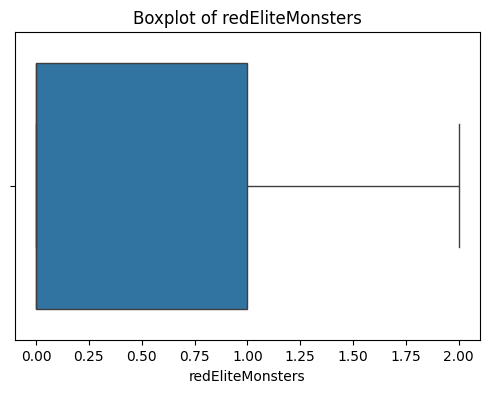

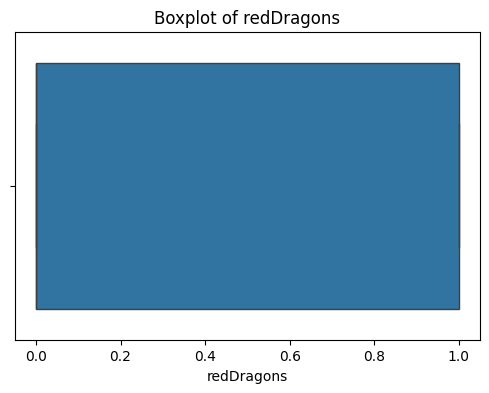

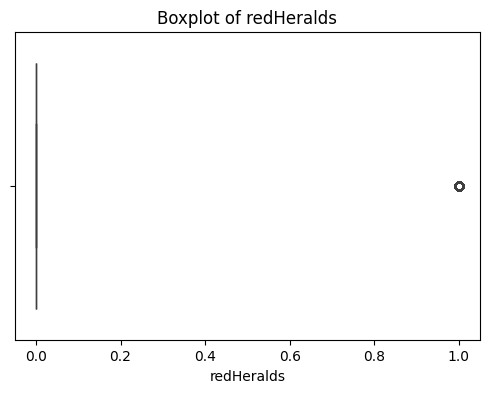

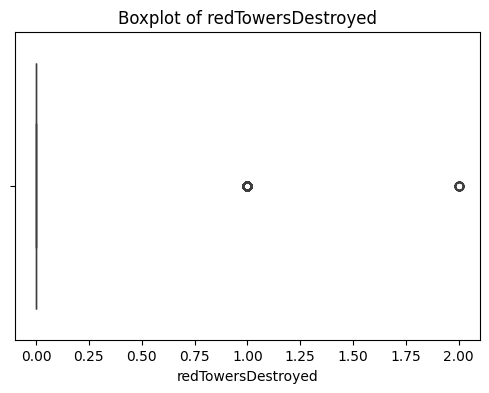

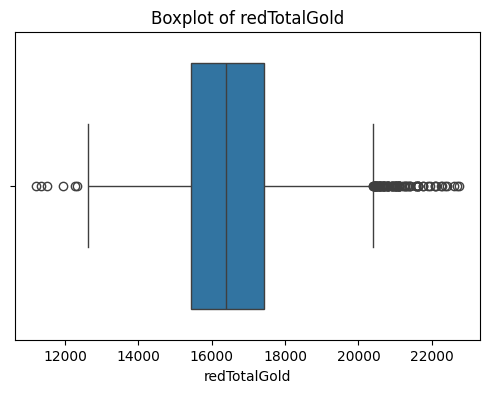

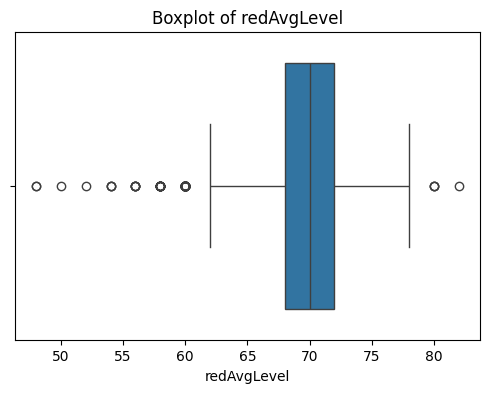

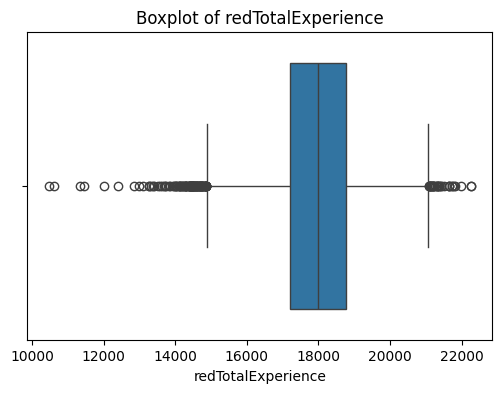

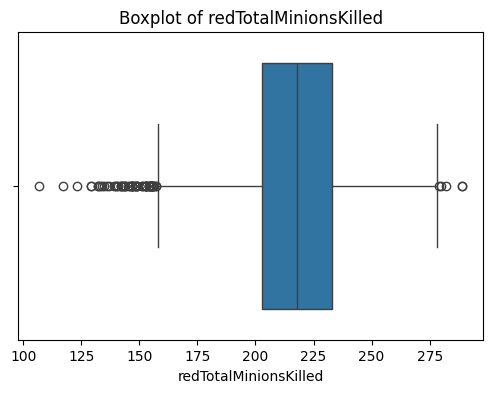

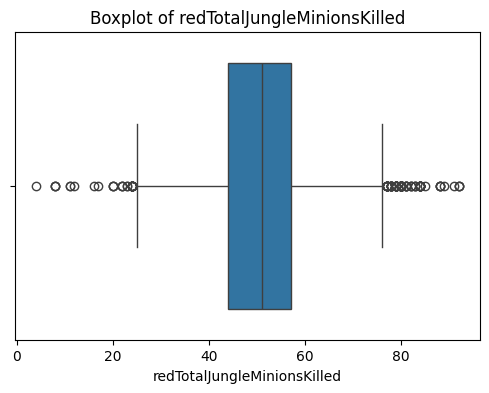

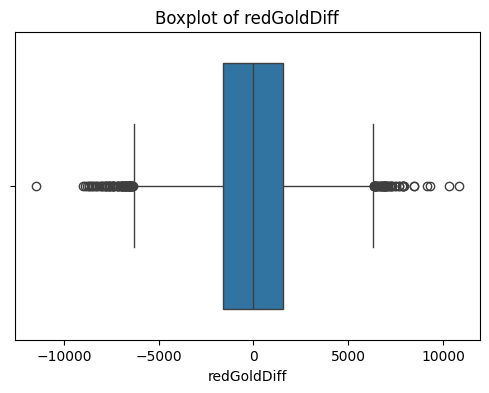

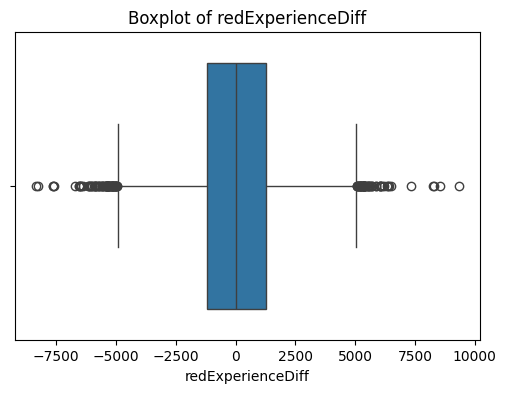

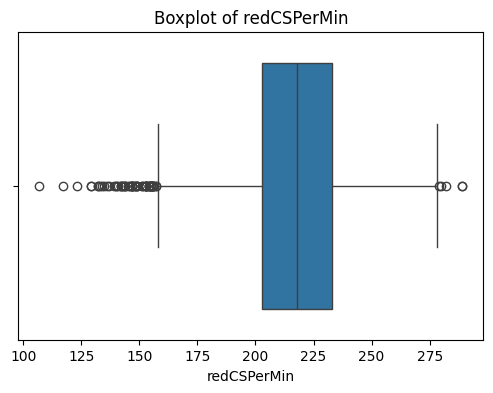

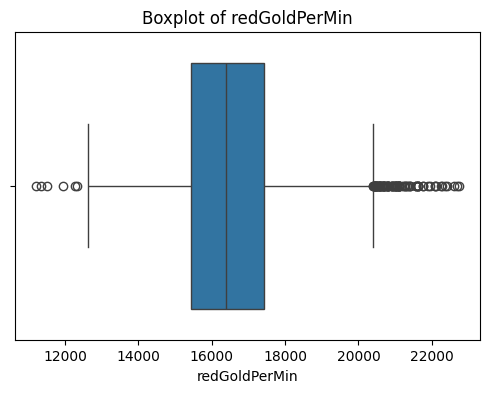


=== Unsupervised visualization section ===


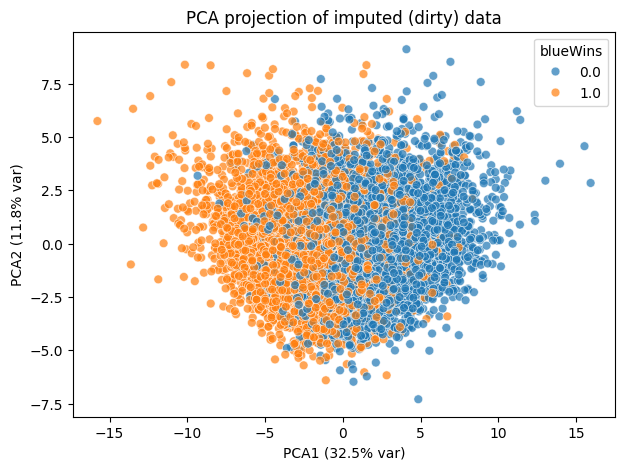

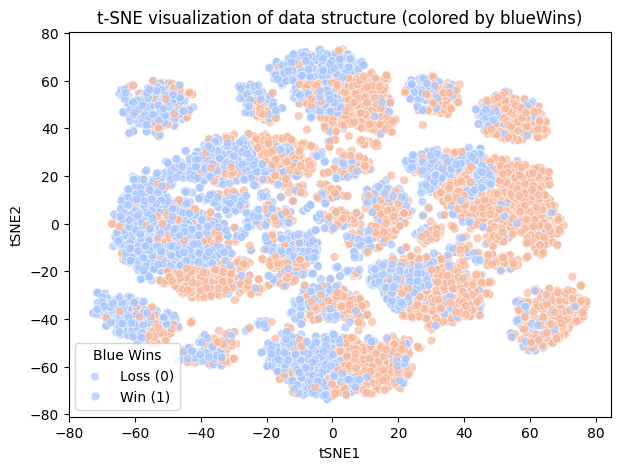

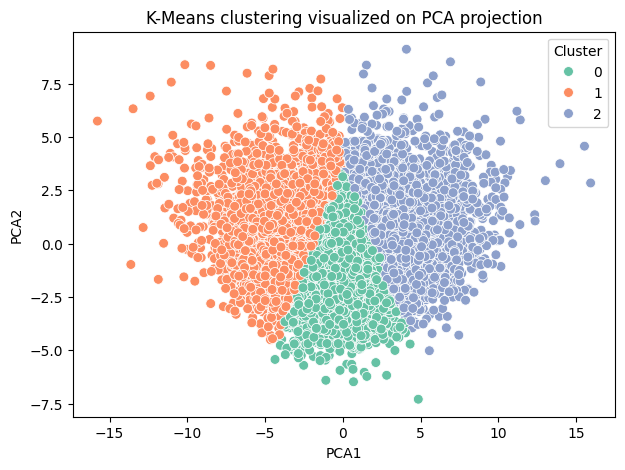

In [ ]:
# Load the videogame data
data = pd.read_csv("Videogamedata_dirty.csv", sep=";")
cleandata = pd.read_csv("Videogamedata.csv")

# Check for duplicates
num_dupes = data['gameId'].duplicated().sum()
print("Number of duplicate game IDs:", num_dupes)

# Remove the row containing the impossible value
data = data[data['blueHeralds'] >= 0]

# Check for missing values
print(data.isnull().sum().sort_values(ascending=False))

# Distribution visualizations
numeric_cols = [col for col in data.select_dtypes(include=['number']).columns if col != 'gameId']

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Imputation (dirty data version)
X = data[numeric_cols]

# Parallelized Iterative Imputer
imp = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1  # enables parallel computation in RF
    ),
    max_iter=3,
    random_state=42
)

X_imputed = imp.fit_transform(X)

imputed_df_dirty = pd.DataFrame(X_imputed, columns=numeric_cols, index=data.index)

## Unsupervised visualization section
# Standardize the data for fair comparison
scaler = StandardScaler()
X_scaled = scaler.fit_transform(imputed_df_dirty)

# PCA for variance and clustering
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
imputed_df_dirty["PCA1"] = pca_result[:, 0]
imputed_df_dirty["PCA2"] = pca_result[:, 1]

plt.figure(figsize=(7, 5))
sns.scatterplot(data=imputed_df_dirty, x="PCA1", y="PCA2", s=40, hue='blueWins', alpha=0.7)
plt.title("PCA projection of imputed (dirty) data")
plt.xlabel(f"PCA1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PCA2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.show()

# t-SNE for non-linear structure visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
tsne_result = tsne.fit_transform(X_scaled)
imputed_df_dirty["tSNE1"] = tsne_result[:, 0]
imputed_df_dirty["tSNE2"] = tsne_result[:, 1]

# Plot colored t-SNE visualization
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=imputed_df_dirty,
    x="tSNE1",
    y="tSNE2",
    hue="blueWins",
    palette="coolwarm",   # red/blue gradient
    s=40,
    alpha=0.7
)
plt.title("t-SNE visualization of data structure (colored by blueWins)")
plt.legend(title="Blue Wins", labels=["Loss (0)", "Win (1)"])
plt.show()

# K-Means clustering visualization
kmeans = KMeans(n_clusters=3, random_state=42)
imputed_df_dirty["Cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=imputed_df_dirty, x="PCA1", y="PCA2", hue="Cluster", palette="Set2", s=50)
plt.title("K-Means clustering visualized on PCA projection")
plt.legend(title="Cluster")
plt.show()

# Testing the parameter settings of the randomforest imputation
- The code below tests how the iterative imputer (with a Random Forest regressor as estimator) converges when filling in missing values:
- Only numeric columns (excluding identifiers like `gameId`) are kept for imputation.
- An IterativeImputer is configured to predict and fill missing values using a random forest regressor.
- For each iteration (1 → max_iter), a separate imputer is fit, and the resulting imputed dataset is stored.
- The mean absolute difference between successive imputed datasets is computed to see how much the imputations are changing.
- The mean absolute change per iteration is plotted. A decreasing curve indicates the imputer is stabilizing.
- If the mean change drops below the threshold (`1e-3`), a message is printed to indicate convergence.
- The code below took ~400 minutes to run without implementing parallel computing, with parallel computing it takes ~45 minutes

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed: 13.2min remaining: 30.7min
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed: 13.3min remaining: 13.3min
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed: 13.3min remaining:  5.7min
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed: 13.3min finished


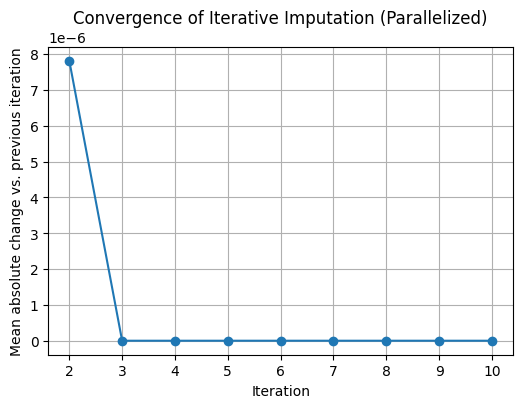

✅ Converged (mean abs. change < 0.001) at iteration 2


In [ ]:
# Use only the numerical columns
numeric_cols = [col for col in data.select_dtypes(include=['number']).columns if col != 'gameId']
X = data[numeric_cols].copy()

# Define max iterations and number of CPU cores
MAX_ITER = 10
N_CORES = -1  # use all available CPU cores (same as in codeblock above)

# Define one iteration of imputation
def run_imputation(iters):
    imp_iter = IterativeImputer(
        estimator=RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=N_CORES  # parallelize Random Forest
        ),
        max_iter=iters,
        random_state=42,
        imputation_order="ascending",
        sample_posterior=False
    )
    X_imp = imp_iter.fit_transform(X)
    return X_imp

# Run imputations in parallel across all iterations
imputed_versions = Parallel(n_jobs=N_CORES, prefer="processes", verbose=10)(
    delayed(run_imputation)(iters) for iters in range(1, MAX_ITER + 1)
)

# Compute the mean absolute change between successive iterations 
mean_abs_changes = [
    np.mean(np.abs(imputed_versions[k] - imputed_versions[k - 1]))
    for k in range(1, len(imputed_versions))
]

# Plot the convergence curve
plt.figure(figsize=(6, 4))
plt.plot(range(2, MAX_ITER + 1), mean_abs_changes, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Mean absolute change vs. previous iteration")
plt.title("Convergence of Iterative Imputation (Parallelized)")
plt.grid(True)
plt.show()

# Print when change falls below a threshold
threshold = 1e-3
for i, change in enumerate(mean_abs_changes, start=2):
    if change < threshold:
        print(f"Converged (mean abs. change < {threshold}) at iteration {i}")
        break

Imputing (parallel): 100%|██████████| 3/3 [45:50<00:00, 916.87s/it]


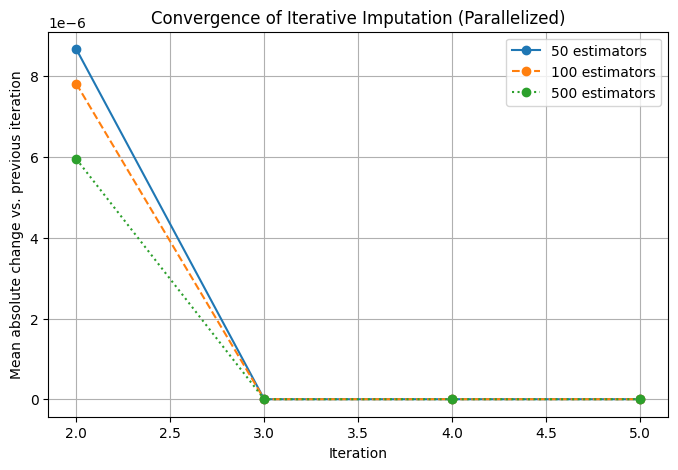

50 estimators converged (mean abs. change < 0.001) at iteration 2
100 estimators converged (mean abs. change < 0.001) at iteration 2
500 estimators converged (mean abs. change < 0.001) at iteration 2


In [ ]:
# Prepare data
numeric_cols = [col for col in data.select_dtypes(include=['number']).columns if col != 'gameId']
X = data[numeric_cols].copy()

# Define max iterations, number of estimators, and CPU cores
max_iter = 5
n_estimators_list = [50, 100, 500]
N_CORES = -1  # use all available cores

# Function for one n_estimators setting
def impute_and_track(n_estimators, max_iter, X):
    imputed_versions = []
    for iters in range(1, max_iter + 1):
        imp_iter = IterativeImputer(
            estimator=RandomForestRegressor(
                n_estimators=n_estimators,
                random_state=42,
                n_jobs=N_CORES  # parallel inside RF
            ),
            max_iter=iters,
            random_state=42,
            imputation_order="ascending",
            sample_posterior=False
        )
        X_imp = imp_iter.fit_transform(X)
        imputed_versions.append(X_imp)

    mean_abs_changes = [
        np.mean(np.abs(imputed_versions[k] - imputed_versions[k - 1]))
        for k in range(1, len(imputed_versions))
    ]
    return n_estimators, mean_abs_changes

# Run in parallel again
results = []
with tqdm(total=len(n_estimators_list), desc="Imputing (parallel)") as pbar:
    parallel_results = Parallel(n_jobs=N_CORES, prefer="processes")(
        delayed(impute_and_track)(n, max_iter, X)
        for n in n_estimators_list
    )
    pbar.update(len(n_estimators_list))

# Collect the results
convergence_curves = dict(parallel_results)

# Plot the results
line_styles = ['-', '--', ':']
colors = plt.cm.tab10.colors

plt.figure(figsize=(8, 5))
for idx, (n_estimators, mean_abs_changes) in enumerate(convergence_curves.items()):
    plt.plot(
        range(2, max_iter + 1),
        mean_abs_changes,
        marker='o',
        color=colors[idx % len(colors)],
        linestyle=line_styles[idx % len(line_styles)],
        label=f"{n_estimators} estimators"
    )

plt.xlabel("Iteration")
plt.ylabel("Mean absolute change vs. previous iteration")
plt.title("Convergence of Iterative Imputation (Parallelized)")
plt.grid(True)
plt.legend()
plt.show()

# Calculate the convergence
threshold = 1e-3
for n_estimators, mean_abs_changes in convergence_curves.items():
    for i, change in enumerate(mean_abs_changes, start=2):
        if change < threshold:
            print(f"{n_estimators} estimators converged (mean abs. change < {threshold}) at iteration {i}")
            break

# Multivariate outlier detection using isolation forest and kNN
This code identifies and removes potential outliers in the imputed dataset using two different algorithms:
   - An `IsolationForest` is fit to the imputed dataset to flag anomalous points.  
   - Outlier labels (`1` = outlier, `0` = inlier) and decision scores (anomaly scores) are added to the DataFrame.  
   - All rows labeled as outliers are removed, producing a cleaned DataFrame (`cleaned_imputed_df_IF`)
   
   - A k-nearest-neighbors (k-NN) based outlier detector is fit on the same imputed data.  
   - Outlier flags and scores are added to a new DataFrame (`imputed_df_KNN`).  
   - Again, rows labeled as outliers are removed, yielding a second cleaned dataset (`cleaned_imputed_df_knn`).
   - The overlap of outliers flagged by both methods is computed.  
   - The overall agreement between the two label sets is printed as a percentage.

Estimated contamination (IQR method): 3.32%
Remaining rows after removing outliers: 9547


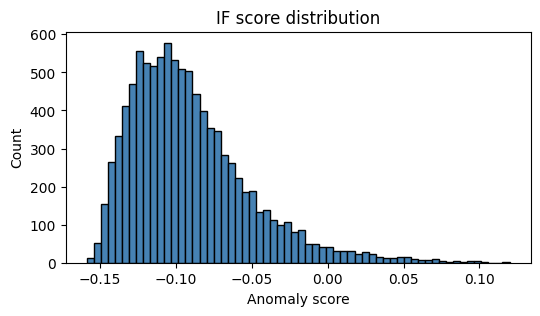

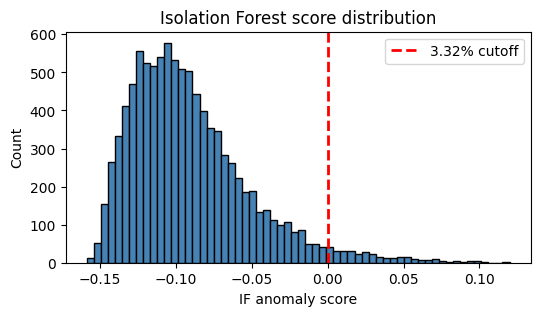

In [ ]:
# Remove the non-feature columns before performing Isolation Forest
exclude_cols = ["blueWins", "PCA1", "PCA2", "tSNE1", "tSNE2", "Cluster"]

imputed_df_IF = imputed_df_dirty.drop(columns=exclude_cols, errors="ignore").copy()

# Run IF once with arbitrary contamination to get the score distribution
clf_temp = IForest(contamination=0.05, n_estimators=200, random_state=42)
clf_temp.fit(imputed_df_IF)
scores_temp = clf_temp.decision_scores_  # higher = more abnormal in PyOD

# Compute IQR-based contamination fraction
q1, q3 = np.percentile(scores_temp, [25, 75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
iqr_fraction_IF = np.mean(scores_temp > upper_bound)
print(f"Estimated contamination (IQR method): {iqr_fraction_IF:.2%}")

# Rerun IF using its own IQR-based contamination fraction
clf = IForest(contamination=iqr_fraction_IF, n_estimators=200, random_state=42)
clf.fit(imputed_df_IF)
labels = clf.labels_
scores = clf.decision_scores_

# Add back results to the full DataFrame for later use
imputed_df_dirty["outlier_flag"] = labels
imputed_df_dirty["outlier_score"] = scores

# Keep only the inliers
cleaned_imputed_df_IF = imputed_df_dirty[imputed_df_dirty["outlier_flag"] == 0].copy()
print("Remaining rows after removing outliers:", cleaned_imputed_df_IF.shape[0])

# Plot baseline score distribution
plt.figure(figsize=(6,3))
plt.hist(scores, bins=60, color="steelblue", edgecolor="k")
plt.title("IF score distribution")
plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.show()

# Plot IF score distribution with IQR cutoff
plt.figure(figsize=(6,3))
plt.hist(scores, bins=60, color="steelblue", edgecolor="k")
t = np.percentile(scores, 100*(1 - iqr_fraction_IF))
plt.axvline(t, color="red", linestyle="--", linewidth=2,
            label=f"{iqr_fraction_IF:.2%} cutoff")
plt.title("Isolation Forest score distribution")
plt.xlabel("IF anomaly score")
plt.ylabel("Count")
plt.legend()
plt.show()


Estimated contamination (IQR method): 6.38%
Remaining rows after removing outliers: 9547
KNN - number of outliers: 630


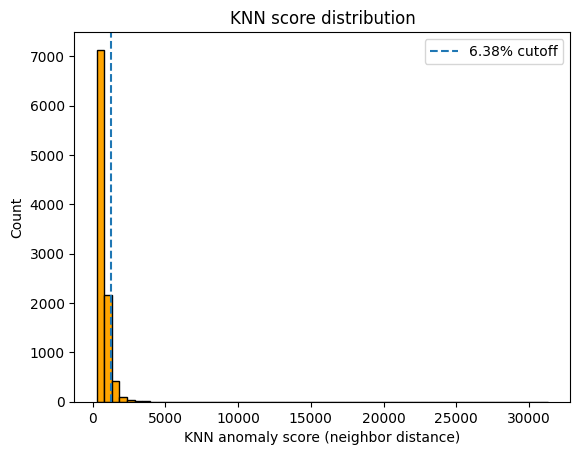

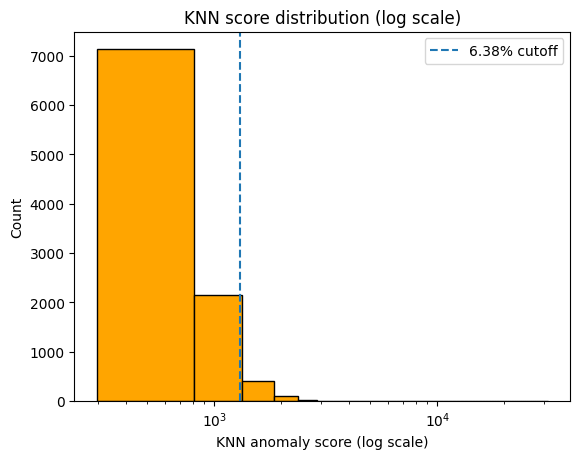

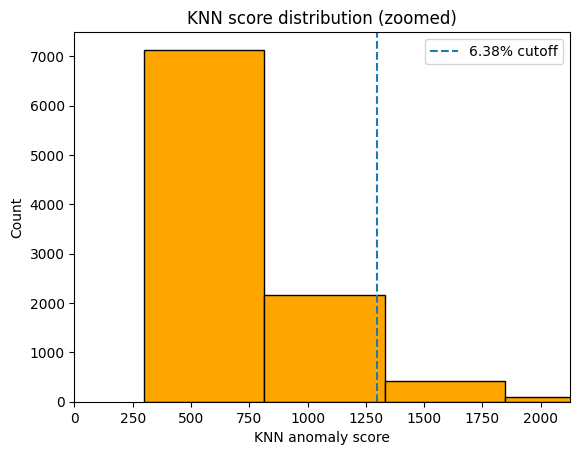

Overlap of IF + KNN outliers: 223
Agreement between IF and KNN: 94.82%


In [ ]:
##kNN section
# Remove non-feature columns
exclude_cols = ["blueWins", "PCA1", "PCA2", "tSNE1", "tSNE2", 
                "Cluster","outlier_flag", "outlier_score"]
imputed_df_IF = imputed_df_dirty.drop(columns=exclude_cols, errors="ignore").copy()

# Run kNN once to get baseline score distribution (same as with IF)
knn = KNN(n_neighbors=5, contamination=0.05, method='largest')
knn.fit(imputed_df_IF)
scores_temp = knn.decision_scores_

# Compute IQR-based contamination based on kNN
q1, q3 = np.percentile(scores_temp, [25, 75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
iqr_fraction = np.mean(scores_temp > upper_bound)
print(f"Estimated contamination (IQR method): {iqr_fraction:.2%}")

# Rerun kNN using its own contamination fraction
knn = KNN(n_neighbors=5, contamination=iqr_fraction, method='largest')
knn.fit(imputed_df_IF)
knn_labels = knn.labels_
knn_scores = knn.decision_scores_

# Add back results to the full DataFrame for later use
imputed_df_dirty["outlier_flag"] = labels
imputed_df_dirty["outlier_score"] = scores

# Keep only inliers
cleaned_imputed_df_IF = imputed_df_dirty[imputed_df_dirty["outlier_flag"] == 0].copy()
print("Remaining rows after removing outliers:", cleaned_imputed_df_IF.shape[0])

# Add kNN results to the imputed_df as new columns
imputed_df_dirty['knn_outlier_flag'] = knn_labels
imputed_df_dirty['knn_outlier_score'] = knn_scores

print("kNN - number of outliers:", (knn_labels == 1).sum())

# Keep only inliers (label == 0)
cleaned_imputed_df_knn = imputed_df_dirty[imputed_df_dirty['knn_outlier_flag'] == 0].copy()

# Plot kNN score distributions
plt.hist(knn_scores, bins=60, color="orange", edgecolor="k")
t = np.percentile(knn_scores, 100*(1-iqr_fraction))
plt.axvline(t, linestyle="--", label=f"{iqr_fraction*100:.2f}% cutoff")
plt.title("kNN score distribution")
plt.xlabel("kNN anomaly score (neighbor distance)")
plt.ylabel("Count")
plt.legend()
plt.show()

# Log scale plot
plt.hist(knn_scores, bins=60, color="orange", edgecolor="k")
t = np.percentile(knn_scores, 100*(1-iqr_fraction))
plt.axvline(t, linestyle="--", label=f"{iqr_fraction*100:.2f}% cutoff")
plt.xscale("log")
plt.title("kNN score distribution (log scale)")
plt.xlabel("kNN anomaly score (log scale)")
plt.ylabel("Count")
plt.legend()
plt.show()

# Zoomed-in plot
plt.hist(knn_scores, bins=60, color="orange", edgecolor="k")
plt.xlim(0, np.percentile(knn_scores, 99))  # zoom into 99th percentile
t = np.percentile(knn_scores, 100*(1-iqr_fraction))
plt.axvline(t, linestyle="--", label=f"{iqr_fraction*100:.2f}% cutoff")
plt.title("kNN score distribution (zoomed)")
plt.xlabel("kNN anomaly score")
plt.ylabel("Count")
plt.legend()
plt.show()

# Compare overlap between IF and kNN methods
overlap = ((labels == 1) & (knn_labels == 1)).sum()
print("Overlap of IF + kNN outliers:", overlap)

# Agreement between IF and KNN methods
agreement = np.mean(labels == knn_labels)
print(f"Agreement between IF and kNN: {agreement:.2%}")

# Neural netork (not yet comparing both data cleaning techniques)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

##Testing neural network
# Define a neural network (MLP)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # two hidden layers with 64 and 32 neurons
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Train
mlp.fit(X_train_scaled, y_train)

# Evaluate
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6629554655870445
              precision    recall  f1-score   support

           0       0.67      0.65      0.66       990
           1       0.66      0.67      0.67       986

    accuracy                           0.66      1976
   macro avg       0.66      0.66      0.66      1976
weighted avg       0.66      0.66      0.66      1976



c:\Users\semmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


# IF Model training, hyperparameter tuning and evaluation
In this section, several machine learning classifiers are trained and evaluated to predict match outcomes (blueWins) based on the 'cleaned' feature set.
- Unnesecary columns are removed from the dataset, the target variable is defined and the features. Data is split into training (85%) and validation (15%) using stratified sampling.
- The models that are used in this block are; Logistic regression, SVM, kNN, Decision tree, Random forest, Gradient boostingn and Naïve bayes
- 5 fold cross validation is performed for hyperparameter tuning using 'GridSearchCV'
- Each model, with its best found parameters, is evaluated on the validation set to estimate the generalized performance of the model

In [ ]:
# Drop unnecessary columns
X = cleaned_imputed_df_IF.drop(columns=['blueWins','outlier_flag','outlier_score',"PCA1", "PCA2", "tSNE1", "tSNE2", "Cluster"], errors='ignore')
y = cleaned_imputed_df_IF['blueWins']

# Split into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models with parameter grids
model_grids = {
    "Logistic Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000))
        ]),
        "params": {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__penalty": ["l2"],
            "clf__solver": ["lbfgs"]
        }
    },
    "SVM (RBF kernel)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(probability=True))
        ]),
        "params": {
            "clf__C": [0.1, 1, 10],
            "clf__gamma": ["scale", "auto"]
        }
    },
    "k-NN": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "params": {
            "clf__n_neighbors": [3, 5, 7, 9],
            "clf__weights": ["uniform", "distance"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [None, 5, 10, 15],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5]
        }
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {}  # No hyperparameters to tune
    }
}

# Scoring metrics
scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "roc_auc_macro": "roc_auc_ovr"
}

# Hyperparameter tuning & CV
results = []

for name, mg in model_grids.items():
    model = mg["model"]
    param_grid = mg["params"]
    
    if param_grid:  # only tune if grid exists
        search = GridSearchCV(model, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        best_params = search.best_params_
    else:
        # No tuning for Naive Bayes
        best_model = model
        best_model.fit(X_train, y_train)
        best_params = {}
    
    scores = cross_validate(best_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({
        "Model": name,
        "Best Params": best_params,
        "Accuracy mean (CV)": scores["test_accuracy"].mean(),
        "F1 macro mean (CV)": scores["test_f1_macro"].mean(),
        "ROC-AUC mean (CV)": scores["test_roc_auc_macro"].mean()
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy mean (CV)", ascending=False).reset_index(drop=True)
print("=== Cross-validation results with hyperparameter optimization ===")
print(results_df)

# Fit all models with best hyperparameters on the full training set
fitted_models = {}

for name, mg in model_grids.items():
    model = mg["model"]
    param_grid = mg["params"]

    if param_grid:
        # Tune hyperparameters with GridSearchCV
        search = GridSearchCV(model, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
    else:
        # No hyperparameters to tune (e.g., Naive Bayes)
        best_model = model
        best_model.fit(X_train, y_train)

    fitted_models[name] = best_model

# Evaluate all models on the validation set
val_results = []

for name, model in fitted_models.items():
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None

    val_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "F1 macro": f1_score(y_val, y_val_pred, average="macro"),
        "ROC-AUC": roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else np.nan
    })

val_results_df = pd.DataFrame(val_results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print("=== Validation set performance for all models ===")
print(val_results_df)


=== Cross-validation results with hyperparameter optimization ===
                 Model                                        Best Params  \
0  Logistic Regression  {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__s...   
1        Random Forest  {'max_depth': 5, 'min_samples_split': 5, 'n_es...   
2     SVM (RBF kernel)             {'clf__C': 0.1, 'clf__gamma': 'scale'}   
3          Naive Bayes                                                 {}   
4    Gradient Boosting  {'learning_rate': 0.01, 'max_depth': 5, 'n_est...   
5        Decision Tree           {'max_depth': 5, 'min_samples_split': 2}   
6                 k-NN  {'clf__n_neighbors': 9, 'clf__weights': 'unifo...   

   Accuracy mean (CV)  F1 macro mean (CV)  ROC-AUC mean (CV)  
0            0.724919            0.724870           0.799962  
1            0.721593            0.721453           0.795954  
2            0.721223            0.721096           0.787845  
3            0.721099            0.721064           0.793373  
4 

# Visualization of hyperparameter tuning
- In this block a function is defined that will perform the GirdSearchCV, extract its results and ranks all parameter combinations by the mean cross-validation accuracy.
- The top performing settings are then visualized with simple bar plots to have a clear overview of which settings are good to use.


=== Running GridSearchCV for Logistic Regression ===


C:\Users\Sem Verstappen\AppData\Local\Temp\ipykernel_15888\3057749940.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


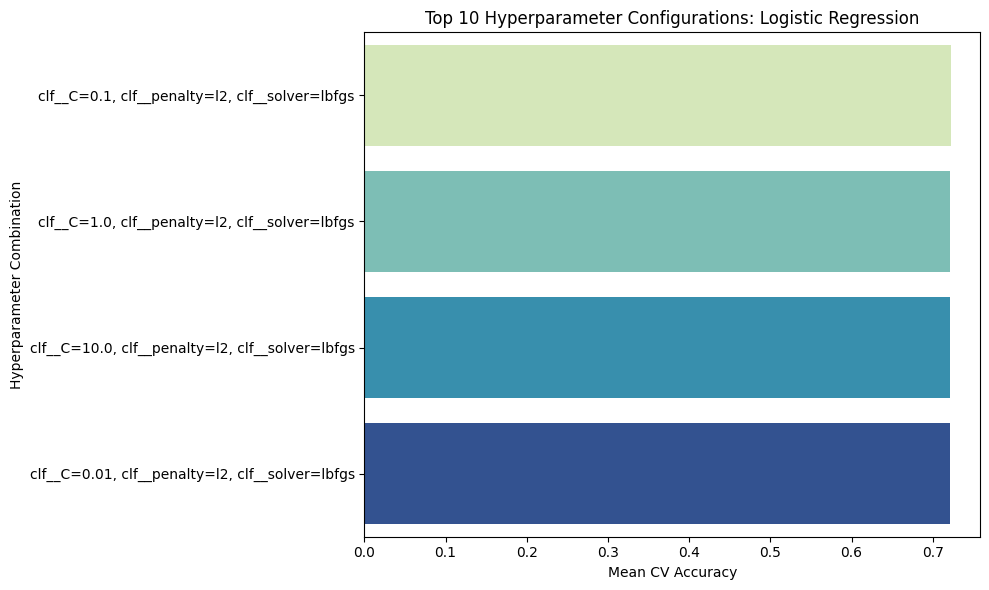


=== Running GridSearchCV for SVM (RBF kernel) ===


C:\Users\Sem Verstappen\AppData\Local\Temp\ipykernel_15888\3057749940.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


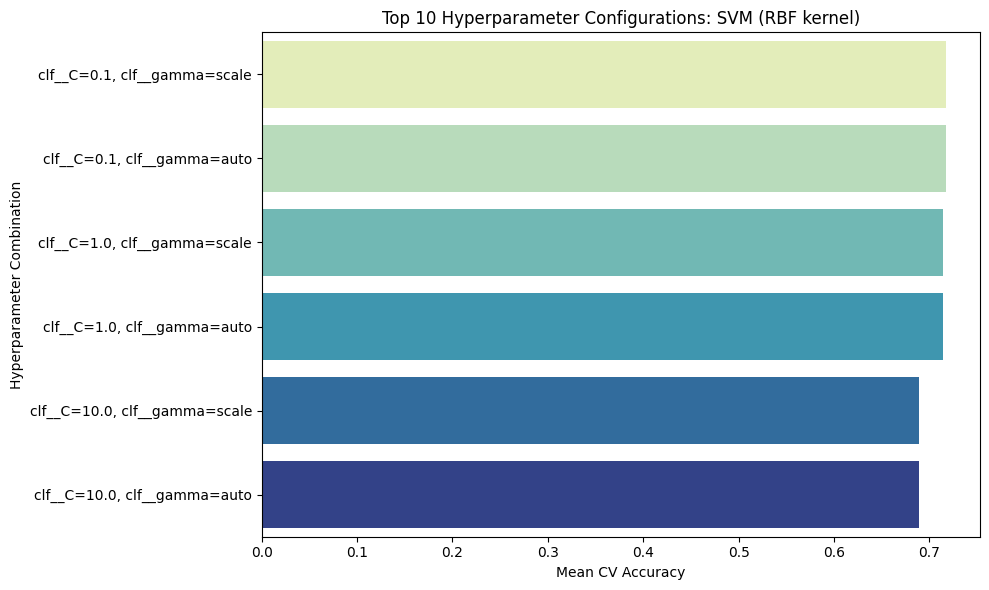


=== Running GridSearchCV for k-NN ===


C:\Users\Sem Verstappen\AppData\Local\Temp\ipykernel_15888\3057749940.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


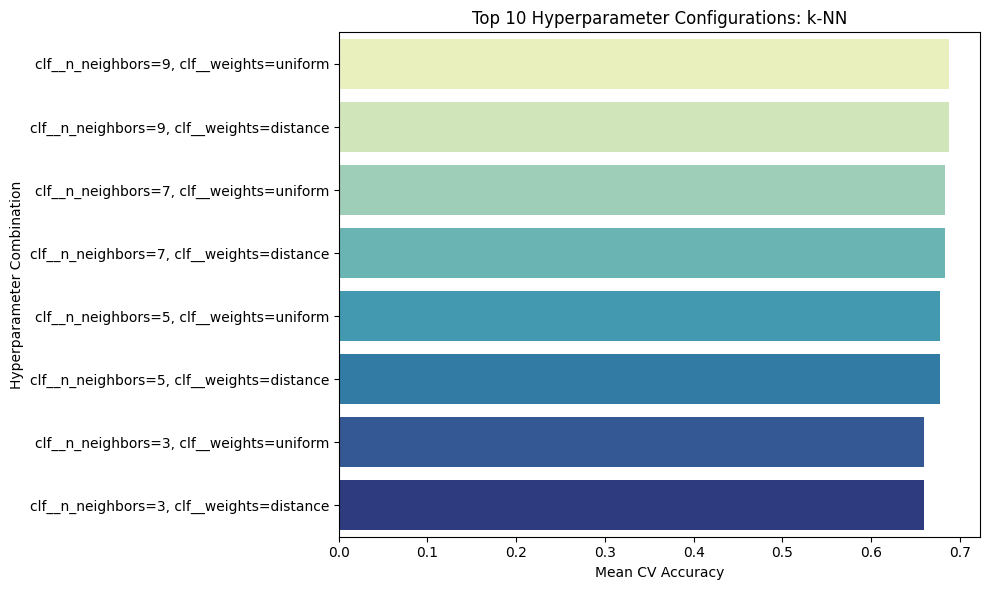


=== Running GridSearchCV for Decision Tree ===


C:\Users\Sem Verstappen\AppData\Local\Temp\ipykernel_15888\3057749940.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


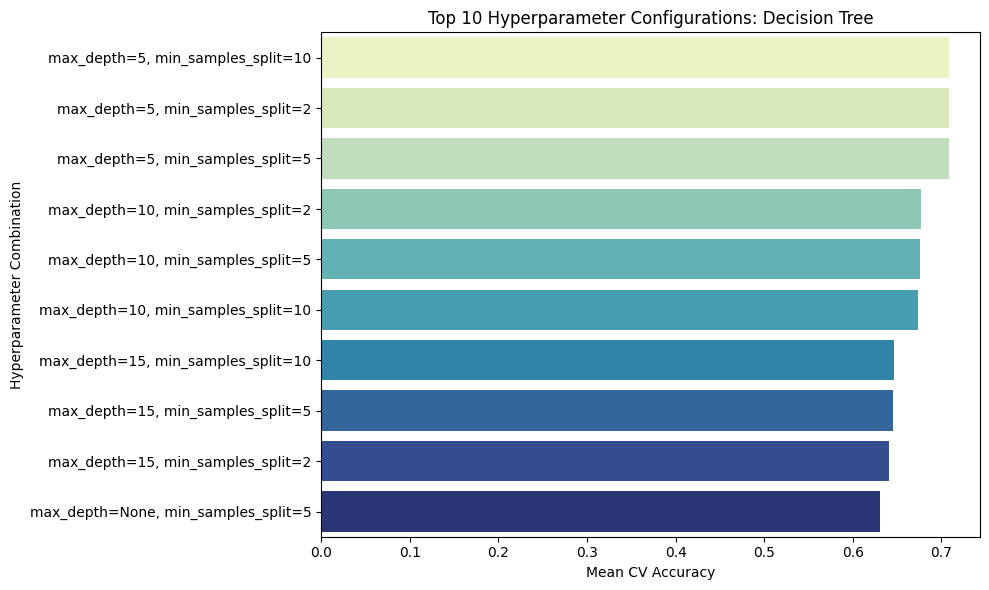


=== Running GridSearchCV for Random Forest ===


C:\Users\Sem Verstappen\AppData\Local\Temp\ipykernel_15888\3057749940.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


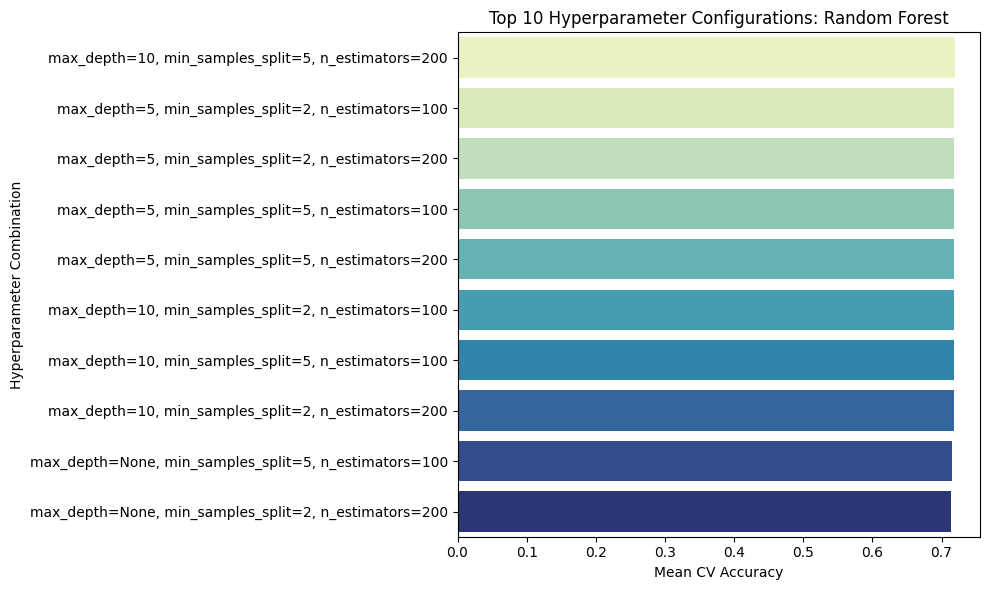


=== Running GridSearchCV for Gradient Boosting ===


C:\Users\Sem Verstappen\AppData\Local\Temp\ipykernel_15888\3057749940.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


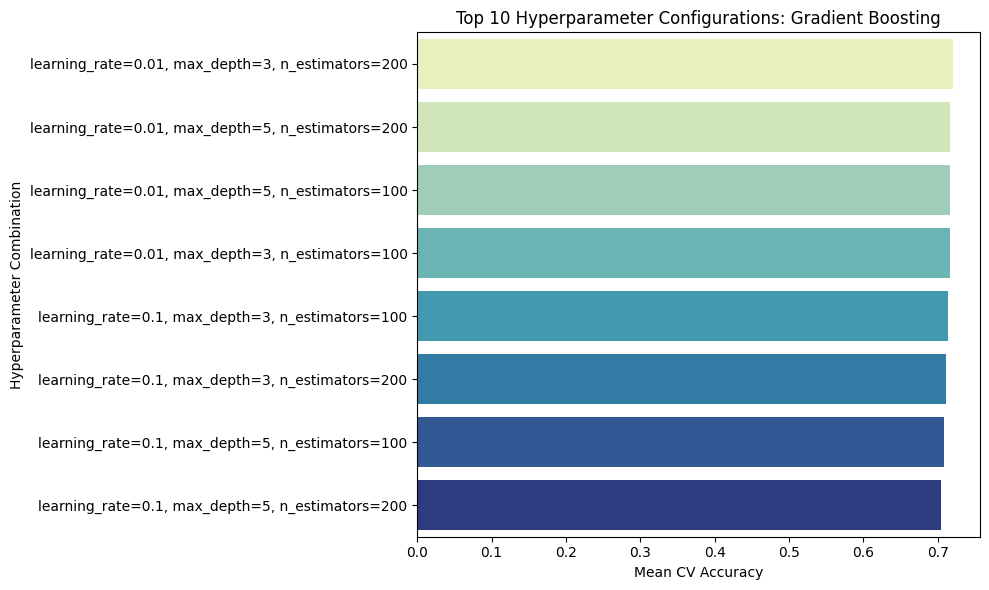

No hyperparameters to tune for Naive Bayes.


In [ ]:
# Full hyperparameter visualization setup

def plot_top_hyperparameter_results(model_name, model, param_grid, X_train, y_train, cv, top_n=10, save=False):
    """
    Runs GridSearchCV and plots the top N hyperparameter combinations by mean CV accuracy.
    Works for any number of hyperparameters.

    Parameters:
    - model_name: str, name of the model (for title and filename)
    - model: sklearn estimator
    - param_grid: dict, hyperparameter grid
    - X_train, y_train: training data
    - cv: cross-validation folds
    - top_n: number of top combinations to plot
    - save: if True, saves each plot as a PNG file
    """
    if not param_grid:
        print(f"No hyperparameters to tune for {model_name}.")
        return

    print(f"\n=== Running GridSearchCV for {model_name} ===")
    search = GridSearchCV(model, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    search.fit(X_train, y_train)

    # Extract and process results
    cv_results = pd.DataFrame(search.cv_results_)
    cv_results = cv_results.sort_values(by='mean_test_score', ascending=False).head(top_n).reset_index(drop=True)

    # Build readable parameter labels for each combination
    cv_results['params_str'] = cv_results.apply(
        lambda row: ", ".join([
            f"{col.replace('param_', '')}={row[col]}" for col in cv_results.columns if col.startswith('param_')
        ]), axis=1
    )

    # Plot top configurations
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=cv_results,
        x='mean_test_score',
        y='params_str',
        palette='YlGnBu'
    )
    plt.xlabel("Mean CV Accuracy")
    plt.ylabel("Hyperparameter Combination")
    plt.title(f"Top {top_n} Hyperparameter Configurations: {model_name}")
    plt.tight_layout()

    # Optionally save the figure
    if save:
        filename = f"top_{top_n}_hyperparams_{model_name.replace(' ', '_').lower()}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"✅ Saved plot as {filename}")

    plt.show()


def run_top_hyperparameter_plots(model_grids, X_train, y_train, cv, top_n=10, save=False):
    """
    Loops through all models in model_grids and plots top hyperparameter results.
    """
    for name, mg in model_grids.items():
        plot_top_hyperparameter_results(
            model_name=name,
            model=mg["model"],
            param_grid=mg["params"],
            X_train=X_train,
            y_train=y_train,
            cv=cv,
            top_n=top_n,
            save=save
        )


# Visualize all models
run_top_hyperparameter_plots(model_grids, X_train, y_train, cv, top_n=10, save=False)


# Isolation forest using no hyperparameter optimization (for comparison)
- This codeblock shows the ML without hyperparameter optimization to just compare the performances with the codeblock above.

In [ ]:
# Drop unnecessary columns
X = cleaned_imputed_df_IF.drop(columns=['blueWins','outlier_flag','outlier_score',"PCA1", "PCA2", "tSNE1", "tSNE2", "Cluster"], errors='ignore')
y = cleaned_imputed_df_IF['blueWins']

# Split into train/test/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# 5-fold stratified CV on training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
    "SVM (RBF kernel)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(probability=True))
    ]),
    "k-NN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ]),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Scoring metrics
scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "roc_auc_macro": "roc_auc_ovr"
}

results = []

# Cross-validate on training data
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({
        "Model": name,
        "Accuracy mean (CV)": scores["test_accuracy"].mean(),
        "F1 macro mean (CV)": scores["test_f1_macro"].mean(),
        "ROC-AUC mean (CV)": scores["test_roc_auc_macro"].mean(),
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy mean (CV)", ascending=False).reset_index(drop=True)
print("=== Cross-validation results ===")
print(results_df)

# Pick best model (e.g. top performer)
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

# Evaluate on validation set
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, "predict_proba") else None

val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average="macro")
val_auc = roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else np.nan

print(f"\n=== Validation performance ({best_model_name}) ===")
print(f"Accuracy: {val_acc:.3f}")
print(f"F1 macro: {val_f1:.3f}")
print(f"ROC-AUC: {val_auc:.3f}")

=== Cross-validation results ===
                 Model  Accuracy mean (CV)  F1 macro mean (CV)  \
0  Logistic Regression            0.723811            0.723760   
1          Naive Bayes            0.721099            0.721064   
2     SVM (RBF kernel)            0.718512            0.718348   
3    Gradient Boosting            0.718018            0.717891   
4        Random Forest            0.713336            0.713211   
5                 k-NN            0.680922            0.680835   
6        Decision Tree            0.621517            0.621463   

   ROC-AUC mean (CV)  
0           0.799961  
1           0.793373  
2           0.776449  
3           0.795169  
4           0.784550  
5           0.736095  
6           0.621528  

=== Validation performance (Logistic Regression) ===
Accuracy: 0.723
F1 macro: 0.723
ROC-AUC: 0.803


# kNN Model training, hyperparameter tuning and evaluation
In this section, several machine learning classifiers are trained and evaluated to predict match outcomes (blueWins) based on the 'cleaned' feature set.
- Unnesecary columns are removed from the dataset, the target variable is defined and the features. Data is split into training (85%) and validation (15%) using stratified sampling.
- The models that are used in this block are; Logistic regression, SVM, kNN, Decision tree, Random forest, Gradient boostingn and Naïve bayes
- 5 fold cross validation is performed for hyperparameter tuning using 'GridSearchCV'
- Each model, with its best found parameters, is evaluated on the validation set to estimate the generalized performance of the model
The code is basically the same as for the IF multivariate outlier detection method but this time it works with the kNN dataset.

In [ ]:
# Drop unnecessary columns
X = cleaned_imputed_df_knn.drop(columns=[
    'blueWins', 'gameId','outlier_flag','outlier_score',
    "PCA1", "PCA2", "tSNE1", "tSNE2", "Cluster",
    'knn_outlier_flag','knn_outlier_score'
], errors='ignore')
y = cleaned_imputed_df_knn['blueWins']

# Split into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models with parameter grids
model_grids = {
    "Logistic Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000))
        ]),
        "params": {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__penalty": ["l2"],
            "clf__solver": ["lbfgs"]
        }
    },
    "SVM (RBF kernel)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(probability=True))
        ]),
        "params": {
            "clf__C": [0.1, 1, 10],
            "clf__gamma": ["scale", "auto"]
        }
    },
    "k-NN": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "params": {
            "clf__n_neighbors": [3, 5, 7, 9],
            "clf__weights": ["uniform", "distance"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [None, 5, 10, 15],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5]
        }
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {}  # No hyperparameters
    }
}

# Scoring metrics
scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "roc_auc_macro": "roc_auc_ovr"
}

# Hyperparameter tuning & cross-validation
cv_results = []
fitted_models = {}

for name, mg in model_grids.items():
    model = mg["model"]
    param_grid = mg["params"]

    if param_grid:
        search = GridSearchCV(model, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        best_params = search.best_params_
    else:
        best_model = model
        best_model.fit(X_train, y_train)
        best_params = {}

    # CV performance
    scores = cross_validate(best_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    cv_results.append({
        "Model": name,
        "Best Params": best_params,
        "Accuracy mean (CV)": scores["test_accuracy"].mean(),
        "F1 macro mean (CV)": scores["test_f1_macro"].mean(),
        "ROC-AUC mean (CV)": scores["test_roc_auc_macro"].mean()
    })

    # Store fitted model for validation evaluation
    fitted_models[name] = best_model

cv_results_df = pd.DataFrame(cv_results).sort_values(by="Accuracy mean (CV)", ascending=False).reset_index(drop=True)
print("=== Cross-validation results with hyperparameter optimization ===")
print(cv_results_df)

# Evaluate all models on the validation set
val_results = []

for name, model in fitted_models.items():
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None

    val_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "F1 macro": f1_score(y_val, y_val_pred, average="macro"),
        "ROC-AUC": roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else np.nan
    })

val_results_df = pd.DataFrame(val_results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print("=== Validation set performance for all models ===")
print(val_results_df)


=== Cross-validation results with hyperparameter optimization ===
                 Model                                        Best Params  \
0  Logistic Regression  {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__so...   
1    Gradient Boosting  {'learning_rate': 0.01, 'max_depth': 3, 'n_est...   
2        Random Forest  {'max_depth': 10, 'min_samples_split': 5, 'n_e...   
3          Naive Bayes                                                 {}   
4     SVM (RBF kernel)             {'clf__C': 0.1, 'clf__gamma': 'scale'}   
5        Decision Tree          {'max_depth': 5, 'min_samples_split': 10}   
6                 k-NN  {'clf__n_neighbors': 9, 'clf__weights': 'unifo...   

   Accuracy mean (CV)  F1 macro mean (CV)  ROC-AUC mean (CV)  
0            0.722070            0.722039           0.796939  
1            0.720924            0.720878           0.795585  
2            0.719652            0.719624           0.792260  
3            0.717488            0.717470           0.791580  
4 

# Visualization of hyperparameter tuning
- In this block a function is defined that will perform the GirdSearchCV, extract its results and ranks all parameter combinations by the mean cross-validation accuracy.
- The top performing settings are then visualized with simple bar plots to have a clear overview of which settings are good to use.
This is the same code for visualization used but this time for the kNN outlier detection dataset.


=== Running GridSearchCV for Logistic Regression ===


C:\Users\Sem Verstappen\AppData\Local\Temp\ipykernel_15888\3037580716.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


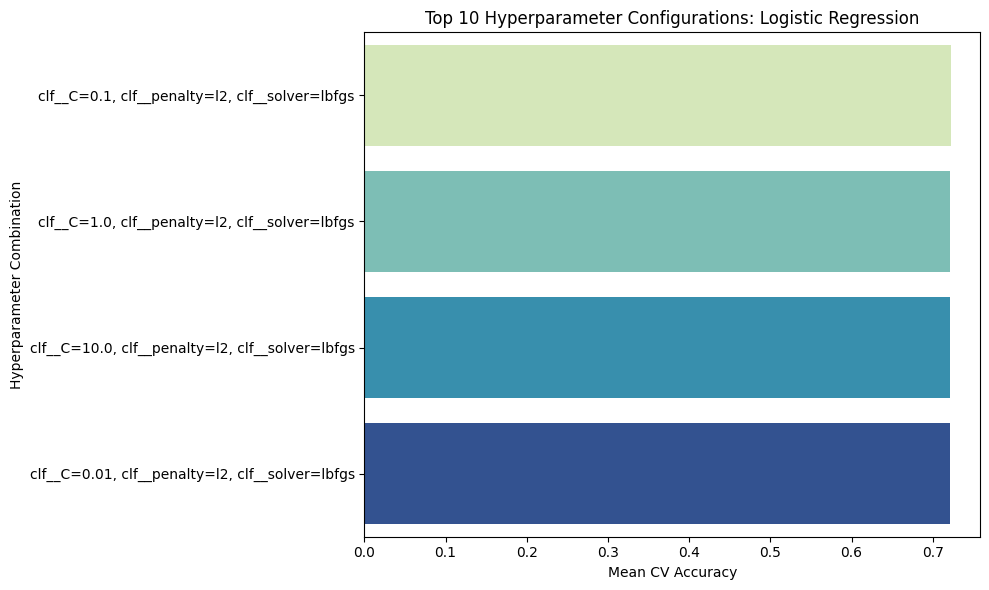


=== Running GridSearchCV for SVM (RBF kernel) ===


C:\Users\Sem Verstappen\AppData\Local\Temp\ipykernel_15888\3037580716.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


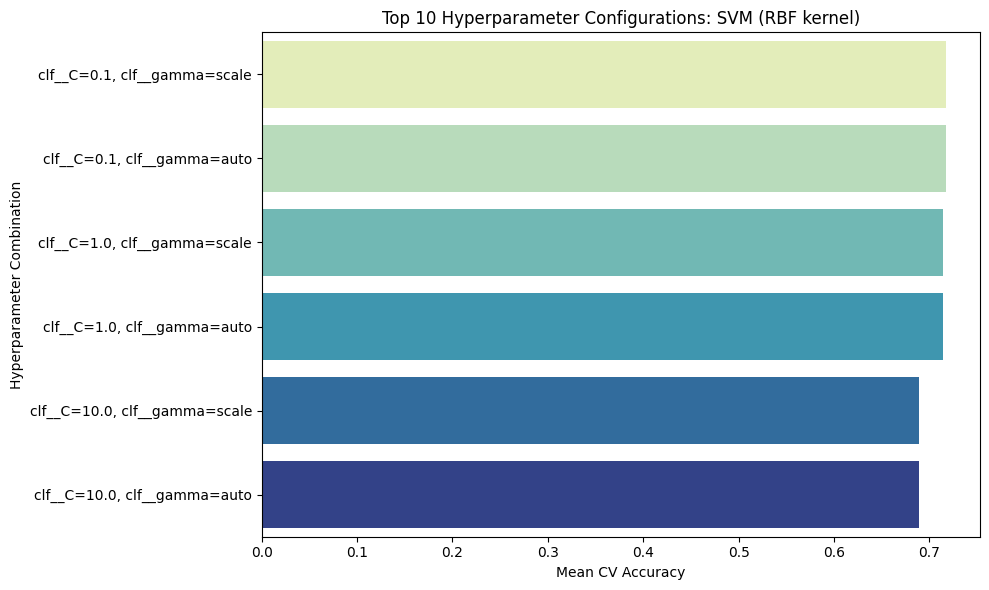


=== Running GridSearchCV for k-NN ===


C:\Users\Sem Verstappen\AppData\Local\Temp\ipykernel_15888\3037580716.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


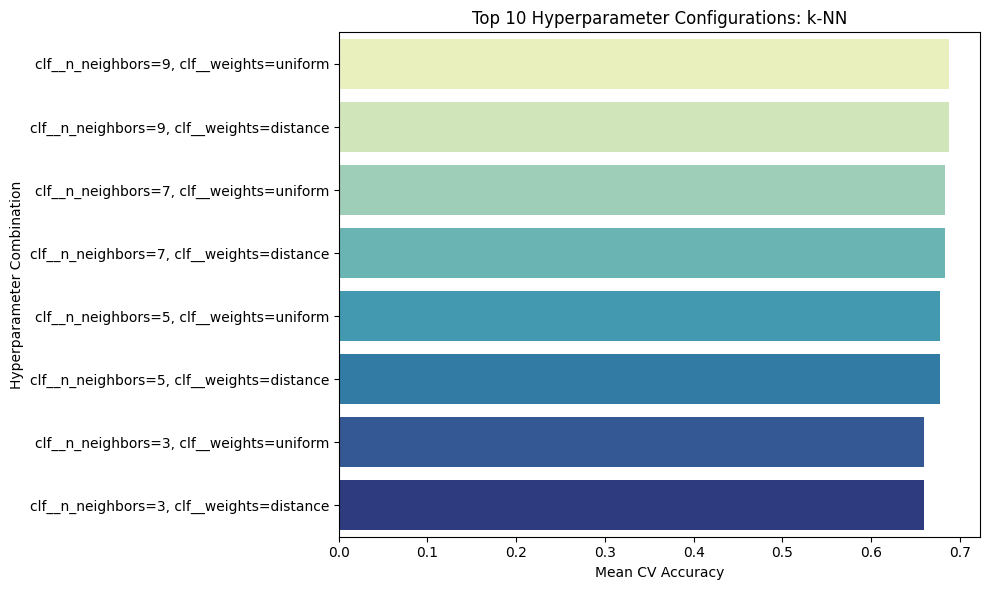


=== Running GridSearchCV for Decision Tree ===


C:\Users\Sem Verstappen\AppData\Local\Temp\ipykernel_15888\3037580716.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


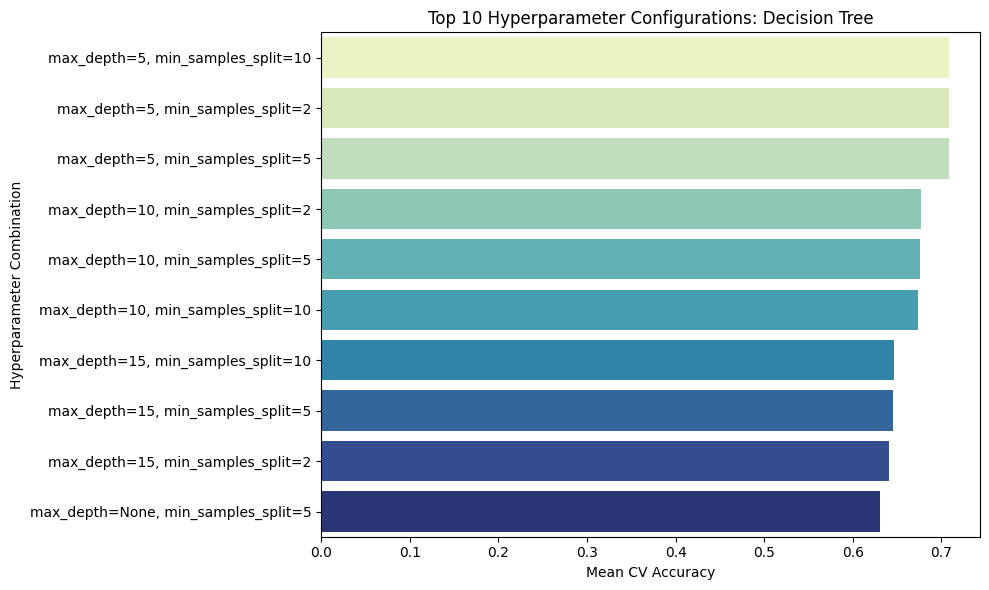


=== Running GridSearchCV for Random Forest ===


C:\Users\Sem Verstappen\AppData\Local\Temp\ipykernel_15888\3037580716.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


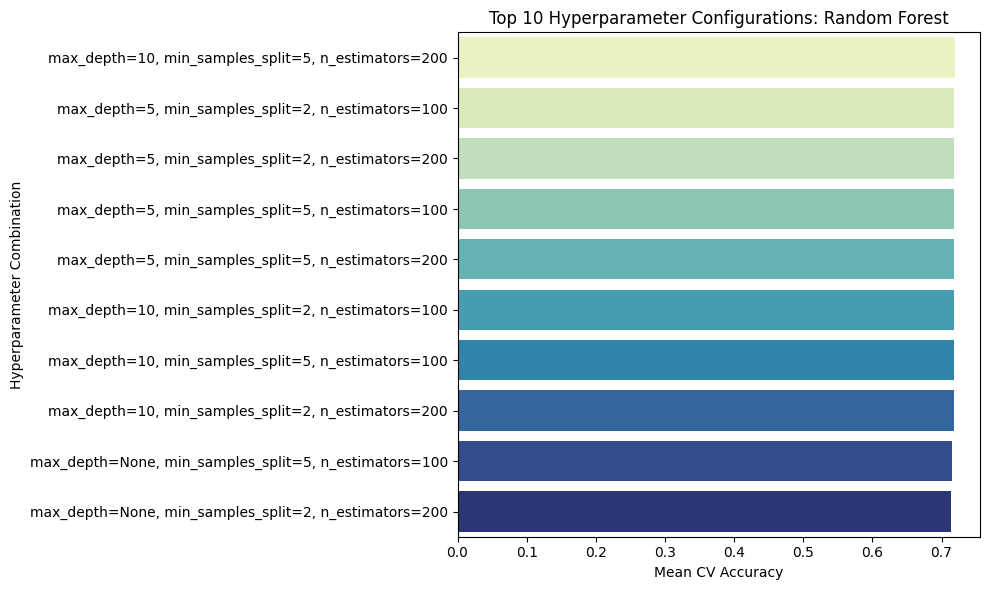


=== Running GridSearchCV for Gradient Boosting ===


C:\Users\Sem Verstappen\AppData\Local\Temp\ipykernel_15888\3037580716.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


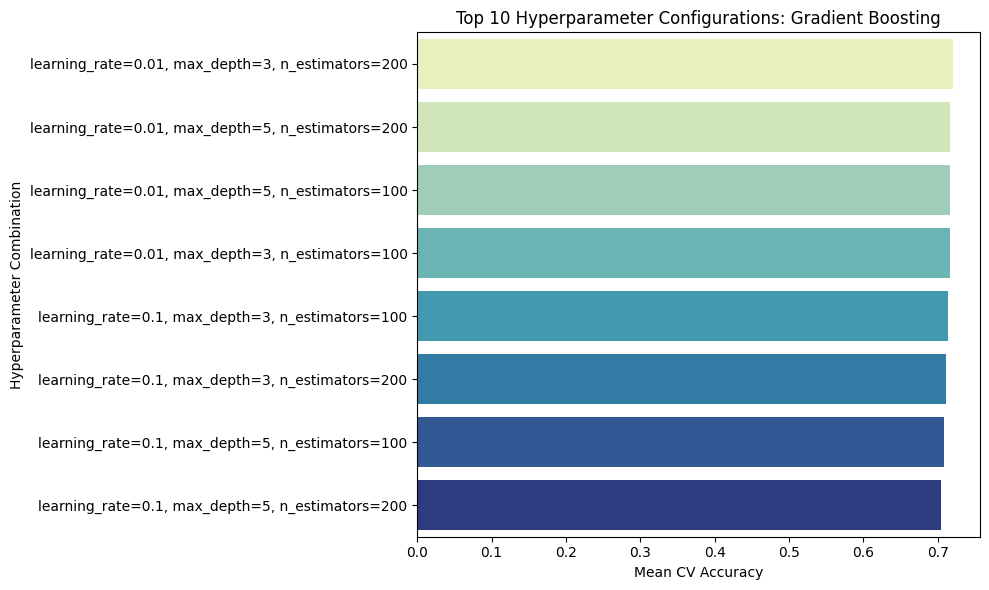

No hyperparameters to tune for Naive Bayes.


In [ ]:
# Full hyperparameter visualization setup

def plot_top_hyperparameter_results(model_name, model, param_grid, X_train, y_train, cv, top_n=10, save=False):
    """
    Runs GridSearchCV and plots the top N hyperparameter combinations by mean CV accuracy.
    Works for any number of hyperparameters.

    Parameters:
    - model_name: str, name of the model (for title and filename)
    - model: sklearn estimator
    - param_grid: dict, hyperparameter grid
    - X_train, y_train: training data
    - cv: cross-validation folds
    - top_n: number of top combinations to plot
    - save: if True, saves each plot as a PNG file
    """
    if not param_grid:
        print(f"No hyperparameters to tune for {model_name}.")
        return

    print(f"\n=== Running GridSearchCV for {model_name} ===")
    search = GridSearchCV(model, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    search.fit(X_train, y_train)

    # Extract and process results
    cv_results = pd.DataFrame(search.cv_results_)
    cv_results = cv_results.sort_values(by='mean_test_score', ascending=False).head(top_n).reset_index(drop=True)

    # Build readable parameter labels for each combination
    cv_results['params_str'] = cv_results.apply(
        lambda row: ", ".join([
            f"{col.replace('param_', '')}={row[col]}" for col in cv_results.columns if col.startswith('param_')
        ]), axis=1
    )

    # Plot top configurations
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=cv_results,
        x='mean_test_score',
        y='params_str',
        palette='YlGnBu'
    )
    plt.xlabel("Mean CV Accuracy")
    plt.ylabel("Hyperparameter Combination")
    plt.title(f"Top {top_n} Hyperparameter Configurations: {model_name}")
    plt.tight_layout()

    # Optionally save the figure
    if save:
        filename = f"top_{top_n}_hyperparams_{model_name.replace(' ', '_').lower()}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"✅ Saved plot as {filename}")

    plt.show()


def run_top_hyperparameter_plots(model_grids, X_train, y_train, cv, top_n=10, save=False):
    """
    Loops through all models in model_grids and plots top hyperparameter results.
    """
    for name, mg in model_grids.items():
        plot_top_hyperparameter_results(
            model_name=name,
            model=mg["model"],
            param_grid=mg["params"],
            X_train=X_train,
            y_train=y_train,
            cv=cv,
            top_n=top_n,
            save=save
        )


# Visualize all models
run_top_hyperparameter_plots(model_grids, X_train, y_train, cv, top_n=10, save=False)

# kNN using no hyperparameter optimization (for comparison)
- This codeblock shows the ML without hyperparameter optimization to just compare the performances with the codeblock above.

In [ ]:
# Drop unnecessary columns
X = cleaned_imputed_df_knn.drop(columns=['blueWins', 'gameId','outlier_flag','outlier_score',"PCA1", "PCA2", "tSNE1", "tSNE2", "Cluster",'knn_outlier_flag','knn_outlier_score'], errors='ignore')
y = cleaned_imputed_df_knn['blueWins']

# Split into train/test/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# define models inside pipelines where needed
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
    "SVM (RBF kernel)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(probability=True))  # probability=True so we can compute ROC-AUC
    ]),
    "k-NN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ]),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Scoring metrics
scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "roc_auc_macro": "roc_auc_ovr"
}

results = []

# Cross-validate on training data
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({
        "Model": name,
        "Accuracy mean (CV)": scores["test_accuracy"].mean(),
        "F1 macro mean (CV)": scores["test_f1_macro"].mean(),
        "ROC-AUC mean (CV)": scores["test_roc_auc_macro"].mean(),
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy mean (CV)", ascending=False).reset_index(drop=True)
print("=== Cross-validation results ===")
print(results_df)

# Pick best model (e.g. top performer)
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

# Evaluate on validation set
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, "predict_proba") else None

val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average="macro")
val_auc = roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else np.nan

print(f"\n=== Validation performance ({best_model_name}) ===")
print(f"Accuracy: {val_acc:.3f}")
print(f"F1 macro: {val_f1:.3f}")
print(f"ROC-AUC: {val_auc:.3f}")

=== Cross-validation results ===
                 Model  Accuracy mean (CV)  F1 macro mean (CV)  \
0  Logistic Regression            0.721815            0.721789   
1          Naive Bayes            0.717488            0.717470   
2    Gradient Boosting            0.714180            0.714121   
3     SVM (RBF kernel)            0.714052            0.714017   
4        Random Forest            0.711761            0.711662   
5                 k-NN            0.678037            0.678006   
6        Decision Tree            0.625098            0.625028   

   ROC-AUC mean (CV)  
0           0.796836  
1           0.791580  
2           0.792561  
3           0.772756  
4           0.782323  
5           0.732317  
6           0.625068  

=== Validation performance (Logistic Regression) ===
Accuracy: 0.727
F1 macro: 0.727
ROC-AUC: 0.802


# Model training, hyperparameter tuning and evaluation
In this section, several machine learning classifiers are trained and evaluated to predict match outcomes (blueWins) based on the 'cleaned' feature set.
- Unnesecary columns are removed from the dataset, the target variable is defined and the features. Data is split into training (85%) and validation (15%) using stratified sampling.
- The models that are used in this block are; Logistic regression, SVM, kNN, Decision tree, Random forest, Gradient boostingn and Naïve bayes
- 5 fold cross validation is performed for hyperparameter tuning using 'GridSearchCV'
- Each model, with its best found parameters, is evaluated on the validation set to estimate the generalized performance of the model
The code is (again) basically the same as the previous ML frameworks but the big difference is that this uses the dirty data without any multivariate outlier detection methods.

In [ ]:
# Define features (X) and target (y)
# Drop identifiers and the target from X
X = imputed_df_dirty.drop(columns=['blueWins', 'gameId','outlier_flag','outlier_score',"PCA1", "PCA2", "tSNE1", "tSNE2", "Cluster",'knn_outlier_flag','knn_outlier_score'], errors='ignore')
y = data['blueWins']  # target column still comes from the original data

# Split into train/test/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models with parameter grids
model_grids = {
    "Logistic Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000))
        ]),
        "params": {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__penalty": ["l2"],
            "clf__solver": ["lbfgs"]
        }
    },
    "SVM (RBF kernel)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(probability=True))
        ]),
        "params": {
            "clf__C": [0.1, 1, 10],
            "clf__gamma": ["scale", "auto"]
        }
    },
    "k-NN": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "params": {
            "clf__n_neighbors": [3, 5, 7, 9],
            "clf__weights": ["uniform", "distance"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [None, 5, 10, 15],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5]
        }
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {}  # No hyperparameters
    }
}

# Scoring metrics
scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "roc_auc_macro": "roc_auc_ovr"
}

# Hyperparameter tuning & cross-validation
cv_results = []
fitted_models = {}

for name, mg in model_grids.items():
    model = mg["model"]
    param_grid = mg["params"]

    if param_grid:
        search = GridSearchCV(model, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        best_params = search.best_params_
    else:
        best_model = model
        best_model.fit(X_train, y_train)
        best_params = {}

    # CV performance
    scores = cross_validate(best_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    cv_results.append({
        "Model": name,
        "Best Params": best_params,
        "Accuracy mean (CV)": scores["test_accuracy"].mean(),
        "F1 macro mean (CV)": scores["test_f1_macro"].mean(),
        "ROC-AUC mean (CV)": scores["test_roc_auc_macro"].mean()
    })

    # Store fitted model for validation evaluation
    fitted_models[name] = best_model

cv_results_df = pd.DataFrame(cv_results).sort_values(by="Accuracy mean (CV)", ascending=False).reset_index(drop=True)
print("=== Cross-validation results with hyperparameter optimization ===")
print(cv_results_df)

# Evaluate all models on the validation set
val_results = []

for name, model in fitted_models.items():
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None

    val_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "F1 macro": f1_score(y_val, y_val_pred, average="macro"),
        "ROC-AUC": roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else np.nan
    })

val_results_df = pd.DataFrame(val_results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print("=== Validation set performance for all models ===")
print(val_results_df)

=== Cross-validation results with hyperparameter optimization ===
                 Model                                        Best Params  \
0  Logistic Regression  {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__so...   
1    Gradient Boosting  {'learning_rate': 0.01, 'max_depth': 3, 'n_est...   
2        Random Forest  {'max_depth': 5, 'min_samples_split': 2, 'n_es...   
3     SVM (RBF kernel)             {'clf__C': 0.1, 'clf__gamma': 'scale'}   
4          Naive Bayes                                                 {}   
5        Decision Tree           {'max_depth': 5, 'min_samples_split': 2}   
6                 k-NN  {'clf__n_neighbors': 9, 'clf__weights': 'unifo...   

   Accuracy mean (CV)  F1 macro mean (CV)  ROC-AUC mean (CV)  
0            0.735254            0.735194           0.810545  
1            0.733586            0.733485           0.808765  
2            0.731559            0.731448           0.807485  
3            0.730250            0.730170           0.795919  
4 